## Imports and project paths

In [1]:
# ============================================================
# 01. Imports and project paths
# ============================================================

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

BASE_DIR = Path.cwd().parent

DATA_PATH = (
    BASE_DIR
    / "data"
    / "synthetic"
    / "earlysignal_monitoring_data.csv"
)

MODEL_DIR = BASE_DIR / "models"
OUTPUT_DIR = BASE_DIR / "outputs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("EARLYSIGNAL AI — ANOMALY DETECTION SETUP")
print("=" * 60)

print("\nBase directory:")
print(BASE_DIR)

print("\nDataset path:")
print(DATA_PATH)

print("\nDataset exists:")
print(DATA_PATH.exists())

print("\nModel directory:")
print(MODEL_DIR)

print("\nOutput directory:")
print(OUTPUT_DIR)

EARLYSIGNAL AI — ANOMALY DETECTION SETUP

Base directory:
C:\Users\Ezekiel Mbaya\myenv\EarlySignal_AI

Dataset path:
C:\Users\Ezekiel Mbaya\myenv\EarlySignal_AI\data\synthetic\earlysignal_monitoring_data.csv

Dataset exists:
True

Model directory:
C:\Users\Ezekiel Mbaya\myenv\EarlySignal_AI\models

Output directory:
C:\Users\Ezekiel Mbaya\myenv\EarlySignal_AI\outputs


## Load the V2 monitoring dataset

In [2]:
# ============================================================
# 02. Load monitoring dataset
# ============================================================

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["reporting_date"]
)

df = (
    df
    .sort_values("reporting_date")
    .reset_index(drop=True)
)

print("=" * 60)
print("ANOMALY DETECTION DATA")
print("=" * 60)

print("\nDataset shape:")
print(df.shape)

print("\nDate range:")
print(
    df["reporting_date"].min(),
    "to",
    df["reporting_date"].max()
)

print("\nKnown synthetic anomalies:")
print(
    df["anomaly_flag"].value_counts()
)

print("\nSynthetic anomaly rate:")
print(
    f"{df['anomaly_flag'].mean():.2%}"
)

ANOMALY DETECTION DATA

Dataset shape:
(7680, 22)

Date range:
2024-01-01 00:00:00 to 2026-08-01 00:00:00

Known synthetic anomalies:
anomaly_flag
0    7488
1     192
Name: count, dtype: int64

Synthetic anomaly rate:
2.50%


## Validate anomaly target

In [3]:
# ============================================================
# 03. Validate anomaly target
# ============================================================

print("=" * 60)
print("ANOMALY TARGET VALIDATION")
print("=" * 60)

print(
    "\nMissing anomaly labels:",
    df["anomaly_flag"].isna().sum()
)

print(
    "Unique anomaly labels:",
    sorted(df["anomaly_flag"].unique())
)

print(
    "Duplicate rows:",
    df.duplicated().sum()
)

print(
    "\nTotal observations:",
    len(df)
)

print(
    "Known anomalies:",
    int(df["anomaly_flag"].sum())
)

print(
    "Known normal records:",
    int(
        (df["anomaly_flag"] == 0).sum()
    )
)

ANOMALY TARGET VALIDATION

Missing anomaly labels: 0
Unique anomaly labels: [np.int64(0), np.int64(1)]
Duplicate rows: 0

Total observations: 7680
Known anomalies: 192
Known normal records: 7488


## Define anomaly detection features

In [4]:
# ============================================================
# 04. Define anomaly detection features
# ============================================================

anomaly_features = [
    "achievement_rate",
    "activity_completion_rate",
    "budget_utilisation_rate",
    "reporting_delay_days",
    "complaints_count",
    "staff_availability_rate",
    "supply_delay_days",
    "previous_month_achievement_rate",
    "access_constraint_score",
    "data_quality_score"
]

print("=" * 60)
print("ANOMALY DETECTION FEATURE SET")
print("=" * 60)

print(
    "\nTotal anomaly features:",
    len(anomaly_features)
)

for feature in anomaly_features:
    print(f" - {feature}")

ANOMALY DETECTION FEATURE SET

Total anomaly features: 10
 - achievement_rate
 - activity_completion_rate
 - budget_utilisation_rate
 - reporting_delay_days
 - complaints_count
 - staff_availability_rate
 - supply_delay_days
 - previous_month_achievement_rate
 - access_constraint_score
 - data_quality_score


## Leakage audit

In [5]:
# ============================================================
# 05. Anomaly detection leakage audit
# ============================================================

forbidden_features = {
    "anomaly_flag",
    "risk_label",
    "recommended_action",
    "record_id",
    "monthly_achievement"
}

selected_features = set(
    anomaly_features
)

potential_leakage = (
    selected_features
    & forbidden_features
)

print("=" * 60)
print("ANOMALY MODEL LEAKAGE AUDIT")
print("=" * 60)

print(
    "\nForbidden features:",
    sorted(forbidden_features)
)

print(
    "\nPotential leakage features:",
    potential_leakage
)

if len(potential_leakage) == 0:
    print("\nLeakage audit: PASSED")
else:
    print("\nLeakage audit: FAILED")

ANOMALY MODEL LEAKAGE AUDIT

Forbidden features: ['anomaly_flag', 'monthly_achievement', 'recommended_action', 'record_id', 'risk_label']

Potential leakage features: set()

Leakage audit: PASSED


## Time-based anomaly train/test split

In [6]:
# ============================================================
# 06. Time-based anomaly train / test split
# ============================================================

model_df = (
    df
    .sort_values("reporting_date")
    .copy()
)

split_date = pd.Timestamp(
    "2026-02-01"
)

train_df = model_df[
    model_df["reporting_date"] < split_date
].copy()

test_df = model_df[
    model_df["reporting_date"] >= split_date
].copy()

print("=" * 60)
print("TIME-BASED ANOMALY TRAIN / TEST SPLIT")
print("=" * 60)

print("\nSplit date:", split_date.date())

print("\nTraining data:")
print("Rows:", len(train_df))
print(
    "Date range:",
    train_df["reporting_date"].min().date(),
    "to",
    train_df["reporting_date"].max().date()
)

print("\nTesting data:")
print("Rows:", len(test_df))
print(
    "Date range:",
    test_df["reporting_date"].min().date(),
    "to",
    test_df["reporting_date"].max().date()
)

TIME-BASED ANOMALY TRAIN / TEST SPLIT

Split date: 2026-02-01

Training data:
Rows: 6000
Date range: 2024-01-01 to 2026-01-01

Testing data:
Rows: 1680
Date range: 2026-02-01 to 2026-08-01


## Check anomaly prevalence across time split

In [7]:
# ============================================================
# 07. Check anomaly prevalence across train and test
# ============================================================

train_anomalies = int(
    train_df["anomaly_flag"].sum()
)

test_anomalies = int(
    test_df["anomaly_flag"].sum()
)

train_anomaly_rate = (
    train_df["anomaly_flag"].mean()
)

test_anomaly_rate = (
    test_df["anomaly_flag"].mean()
)

print("=" * 60)
print("ANOMALY PREVALENCE — TRAIN VS TEST")
print("=" * 60)

print(
    f"\nTraining anomalies: "
    f"{train_anomalies:,} "
    f"({train_anomaly_rate:.2%})"
)

print(
    f"Testing anomalies:  "
    f"{test_anomalies:,} "
    f"({test_anomaly_rate:.2%})"
)

print(
    "\nOverall anomaly rate:",
    f"{df['anomaly_flag'].mean():.2%}"
)

ANOMALY PREVALENCE — TRAIN VS TEST

Training anomalies: 146 (2.43%)
Testing anomalies:  46 (2.74%)

Overall anomaly rate: 2.50%


## Inspect anomaly vs normal operational patterns

In [8]:
# ============================================================
# 08. Compare normal and known anomaly patterns
# ============================================================

pattern_features = [
    "achievement_rate",
    "activity_completion_rate",
    "reporting_delay_days",
    "complaints_count",
    "supply_delay_days",
    "access_constraint_score",
    "data_quality_score"
]

anomaly_pattern_summary = (
    df
    .groupby("anomaly_flag")[
        pattern_features
    ]
    .mean()
    .T
)

anomaly_pattern_summary.columns = [
    "Normal Mean",
    "Anomaly Mean"
]

anomaly_pattern_summary[
    "Difference"
] = (
    anomaly_pattern_summary["Anomaly Mean"]
    - anomaly_pattern_summary["Normal Mean"]
)

print("=" * 70)
print("NORMAL VS KNOWN ANOMALY PATTERNS")
print("=" * 70)

display(
    anomaly_pattern_summary.round(4)
)

NORMAL VS KNOWN ANOMALY PATTERNS


,Normal Mean,Anomaly Mean,Difference
achievement_rate,0.7313,0.6328,-0.0985
activity_completion_rate,0.7479,0.7493,0.0014
reporting_delay_days,5.0198,12.9948,7.9750
complaints_count,3.0276,8.8281,5.8005
supply_delay_days,5.3815,13.4219,8.0403
access_constraint_score,0.3036,0.3038,0.0001
data_quality_score,0.9031,0.9018,-0.0014


## Prepare anomaly matrices

In [9]:
# ============================================================
# 09. Prepare anomaly detection matrices
# ============================================================

X_train = train_df[
    anomaly_features
].copy()

X_test = test_df[
    anomaly_features
].copy()

y_test_anomaly = test_df[
    "anomaly_flag"
].copy()

print("=" * 60)
print("ANOMALY DETECTION MATRICES")
print("=" * 60)

print(
    "\nX_train shape:",
    X_train.shape
)

print(
    "X_test shape:",
    X_test.shape
)

print(
    "y_test shape:",
    y_test_anomaly.shape
)

print(
    "\nMissing values in X_train:",
    X_train.isna().sum().sum()
)

print(
    "Missing values in X_test:",
    X_test.isna().sum().sum()
)

print(
    "\nTarget included in model features:",
    "anomaly_flag" in X_train.columns
)

ANOMALY DETECTION MATRICES

X_train shape: (6000, 10)
X_test shape: (1680, 10)
y_test shape: (1680,)

Missing values in X_train: 0
Missing values in X_test: 0

Target included in model features: False


## Build Isolation Forest pipeline

In [10]:
# ============================================================
# 10. Build Isolation Forest anomaly pipeline
# ============================================================

anomaly_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            anomaly_features
        )
    ],
    remainder="drop"
)

anomaly_detector = IsolationForest(
    n_estimators=300,
    contamination=0.025,
    random_state=42,
    n_jobs=-1
)

anomaly_model = Pipeline(
    steps=[
        (
            "preprocessor",
            anomaly_preprocessor
        ),
        (
            "model",
            anomaly_detector
        )
    ]
)

print("=" * 60)
print("ISOLATION FOREST CONFIGURATION")
print("=" * 60)

print("\nEstimators: 300")
print("Contamination assumption: 2.50%")
print("Random state: 42")

print(
    "\nIsolation Forest pipeline "
    "created successfully."
)

print(
    "\nMethod note: anomaly_flag is reserved "
    "for evaluation and is not used to train the detector."
)

ISOLATION FOREST CONFIGURATION

Estimators: 300
Contamination assumption: 2.50%
Random state: 42

Isolation Forest pipeline created successfully.

Method note: anomaly_flag is reserved for evaluation and is not used to train the detector.


## Train Isolation Forest

In [11]:
# ============================================================
# 11. Train Isolation Forest anomaly detector
# ============================================================

anomaly_model.fit(
    X_train
)

print("=" * 60)
print("ANOMALY MODEL TRAINING")
print("=" * 60)

print(
    "\nIsolation Forest training complete."
)

print(
    "Training observations:",
    len(X_train)
)

print(
    "Known anomaly labels used in training: False"
)

ANOMALY MODEL TRAINING

Isolation Forest training complete.
Training observations: 6000
Known anomaly labels used in training: False


## Generate anomaly predictions and scores

In [12]:
# ============================================================
# 12. Generate anomaly predictions and scores
# ============================================================

raw_predictions = anomaly_model.predict(
    X_test
)

decision_scores = anomaly_model.decision_function(
    X_test
)

anomaly_predictions = (
    raw_predictions == -1
).astype(int)

anomaly_scores = (
    -decision_scores
)

print("=" * 60)
print("ANOMALY PREDICTIONS GENERATED")
print("=" * 60)

print(
    "\nPredictions generated:",
    len(anomaly_predictions)
)

print(
    "Predicted anomalies:",
    int(anomaly_predictions.sum())
)

print(
    "Predicted normal records:",
    int(
        (anomaly_predictions == 0).sum()
    )
)

print(
    "\nPredicted anomaly rate:",
    f"{anomaly_predictions.mean():.2%}"
)

print(
    "\nAnomaly score range:"
)

print(
    f"Minimum: {anomaly_scores.min():.4f}"
)

print(
    f"Maximum: {anomaly_scores.max():.4f}"
)

print(
    "\nScore interpretation: larger values "
    "indicate more unusual observations."
)

ANOMALY PREDICTIONS GENERATED

Predictions generated: 1680
Predicted anomalies: 35
Predicted normal records: 1645

Predicted anomaly rate: 2.08%

Anomaly score range:
Minimum: -0.1483
Maximum: 0.0976

Score interpretation: larger values indicate more unusual observations.


## Core anomaly detection metrics

In [13]:
# ============================================================
# 13. Evaluate anomaly detection performance
# ============================================================

anomaly_precision = precision_score(
    y_test_anomaly,
    anomaly_predictions,
    zero_division=0
)

anomaly_recall = recall_score(
    y_test_anomaly,
    anomaly_predictions,
    zero_division=0
)

anomaly_f1 = f1_score(
    y_test_anomaly,
    anomaly_predictions,
    zero_division=0
)

print("=" * 60)
print("ANOMALY DETECTION PERFORMANCE")
print("=" * 60)

print(
    f"\nPrecision: {anomaly_precision:.4f}"
)

print(
    f"Recall:    {anomaly_recall:.4f}"
)

print(
    f"F1 Score:  {anomaly_f1:.4f}"
)

print(
    "\nEvaluation note: synthetic anomaly flags "
    "are used only for held-out validation."
)

ANOMALY DETECTION PERFORMANCE

Precision: 0.6571
Recall:    0.5000
F1 Score:  0.5679

Evaluation note: synthetic anomaly flags are used only for held-out validation.


## Anomaly confusion matrix

In [14]:
# ============================================================
# 14. Anomaly detection confusion matrix
# ============================================================

anomaly_cm = confusion_matrix(
    y_test_anomaly,
    anomaly_predictions,
    labels=[0, 1]
)

anomaly_confusion_df = pd.DataFrame(
    anomaly_cm,
    index=[
        "Actual Normal",
        "Actual Anomaly"
    ],
    columns=[
        "Predicted Normal",
        "Predicted Anomaly"
    ]
)

print("=" * 70)
print("ANOMALY DETECTION CONFUSION MATRIX")
print("=" * 70)

display(
    anomaly_confusion_df
)

ANOMALY DETECTION CONFUSION MATRIX


,Predicted Normal,Predicted Anomaly
Actual Normal,1622,12
Actual Anomaly,23,23


## Operational anomaly detection audit

In [15]:
# ============================================================
# 15. Operational anomaly detection audit
# ============================================================

tn, fp, fn, tp = anomaly_cm.ravel()

print("=" * 60)
print("ANOMALY DETECTION AUDIT")
print("=" * 60)

print(
    f"\nKnown anomalies in test set: "
    f"{int(tp + fn):,}"
)

print(
    f"Anomalies detected:          "
    f"{int(tp):,}"
)

print(
    f"Anomalies missed:            "
    f"{int(fn):,}"
)

print(
    f"False anomaly alerts:        "
    f"{int(fp):,}"
)

print(
    f"Correct normal records:      "
    f"{int(tn):,}"
)

print(
    f"\nRecall of known anomalies: "
    f"{anomaly_recall:.2%}"
)

print(
    "\nDecision-use note: anomaly alerts identify "
    "unusual monitoring patterns recommended for human review."
)

ANOMALY DETECTION AUDIT

Known anomalies in test set: 46
Anomalies detected:          23
Anomalies missed:            23
False anomaly alerts:        12
Correct normal records:      1,622

Recall of known anomalies: 50.00%

Decision-use note: anomaly alerts identify unusual monitoring patterns recommended for human review.


## Confusion matrix visualization

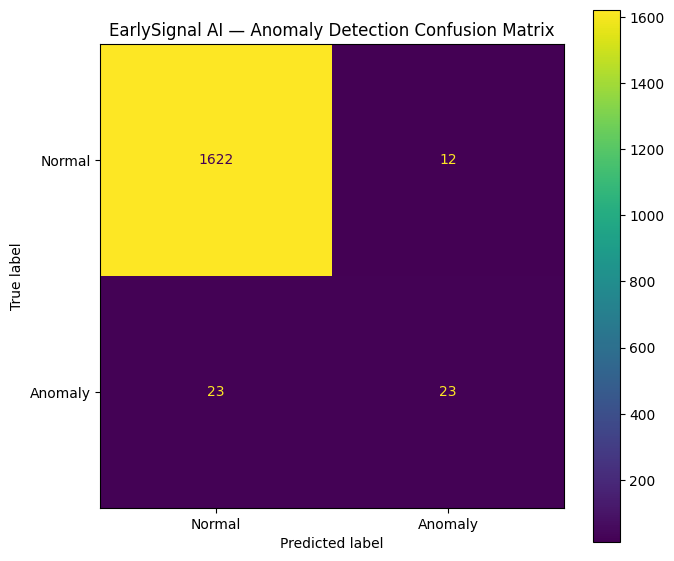

In [16]:
# ============================================================
# 16. Visualize anomaly confusion matrix
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=anomaly_cm,
    display_labels=[
        "Normal",
        "Anomaly"
    ]
)

display_cm.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "EarlySignal AI — Anomaly Detection Confusion Matrix"
)

plt.tight_layout()
plt.show()

## Create training validation split

In [17]:
# ============================================================
# 17. Create development / validation periods
# ============================================================

validation_start = pd.Timestamp(
    "2025-08-01"
)

development_df = train_df[
    train_df["reporting_date"] < validation_start
].copy()

validation_df = train_df[
    train_df["reporting_date"] >= validation_start
].copy()

print("=" * 65)
print("ANOMALY DEVELOPMENT / VALIDATION SPLIT")
print("=" * 65)

print("\nDevelopment period:")
print("Rows:", len(development_df))
print(
    "Dates:",
    development_df["reporting_date"].min().date(),
    "to",
    development_df["reporting_date"].max().date()
)

print("\nValidation period:")
print("Rows:", len(validation_df))
print(
    "Dates:",
    validation_df["reporting_date"].min().date(),
    "to",
    validation_df["reporting_date"].max().date()
)

print(
    "\nDevelopment anomaly rate:",
    f"{development_df['anomaly_flag'].mean():.2%}"
)

print(
    "Validation anomaly rate:",
    f"{validation_df['anomaly_flag'].mean():.2%}"
)

ANOMALY DEVELOPMENT / VALIDATION SPLIT

Development period:
Rows: 4560
Dates: 2024-01-01 to 2025-07-01

Validation period:
Rows: 1440
Dates: 2025-08-01 to 2026-01-01

Development anomaly rate: 2.57%
Validation anomaly rate: 2.01%


## Define candidate feature sets

In [18]:
# ============================================================
# 18. Define candidate anomaly feature sets
# ============================================================

candidate_feature_sets = {
    "All Operational Signals": [
        "achievement_rate",
        "activity_completion_rate",
        "budget_utilisation_rate",
        "reporting_delay_days",
        "complaints_count",
        "staff_availability_rate",
        "supply_delay_days",
        "previous_month_achievement_rate",
        "access_constraint_score",
        "data_quality_score"
    ],

    "Core Warning Signals": [
        "achievement_rate",
        "reporting_delay_days",
        "complaints_count",
        "supply_delay_days"
    ],

    "Core + Implementation Context": [
        "achievement_rate",
        "activity_completion_rate",
        "reporting_delay_days",
        "complaints_count",
        "staff_availability_rate",
        "supply_delay_days",
        "access_constraint_score"
    ]
}

print("=" * 65)
print("CANDIDATE ANOMALY FEATURE SETS")
print("=" * 65)

for name, features in candidate_feature_sets.items():
    print(
        f"\n{name}: {len(features)} features"
    )

    for feature in features:
        print(f" - {feature}")

CANDIDATE ANOMALY FEATURE SETS

All Operational Signals: 10 features
 - achievement_rate
 - activity_completion_rate
 - budget_utilisation_rate
 - reporting_delay_days
 - complaints_count
 - staff_availability_rate
 - supply_delay_days
 - previous_month_achievement_rate
 - access_constraint_score
 - data_quality_score

Core Warning Signals: 4 features
 - achievement_rate
 - reporting_delay_days
 - complaints_count
 - supply_delay_days

Core + Implementation Context: 7 features
 - achievement_rate
 - activity_completion_rate
 - reporting_delay_days
 - complaints_count
 - staff_availability_rate
 - supply_delay_days
 - access_constraint_score


## Compare configurations on validation period

In [19]:
# ============================================================
# 19. Compare Isolation Forest configurations
# ============================================================

contamination_values = [
    0.020,
    0.025,
    0.030,
    0.040,
    0.050
]

configuration_results = []

for feature_set_name, features in candidate_feature_sets.items():

    X_dev = development_df[
        features
    ].copy()

    X_val = validation_df[
        features
    ].copy()

    y_val = validation_df[
        "anomaly_flag"
    ].copy()

    for contamination in contamination_values:

        candidate_model = Pipeline(
            steps=[
                (
                    "preprocessor",
                    ColumnTransformer(
                        transformers=[
                            (
                                "numeric",
                                StandardScaler(),
                                features
                            )
                        ],
                        remainder="drop"
                    )
                ),
                (
                    "model",
                    IsolationForest(
                        n_estimators=300,
                        contamination=contamination,
                        random_state=42,
                        n_jobs=-1
                    )
                )
            ]
        )

        candidate_model.fit(
            X_dev
        )

        candidate_raw = candidate_model.predict(
            X_val
        )

        candidate_pred = (
            candidate_raw == -1
        ).astype(int)

        precision = precision_score(
            y_val,
            candidate_pred,
            zero_division=0
        )

        recall = recall_score(
            y_val,
            candidate_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_val,
            candidate_pred,
            zero_division=0
        )

        configuration_results.append({
            "Feature Set": feature_set_name,
            "Contamination": contamination,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Predicted Anomalies": int(
                candidate_pred.sum()
            )
        })

configuration_results_df = (
    pd.DataFrame(configuration_results)
    .sort_values(
        ["F1", "Recall", "Precision"],
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 75)
print("ISOLATION FOREST CONFIGURATION COMPARISON")
print("=" * 75)

display(
    configuration_results_df.round(4)
)

ISOLATION FOREST CONFIGURATION COMPARISON


,Feature Set,Contamination,Precision,Recall,F1,Predicted Anomalies
0,Core Warning Signals,0.020,0.6765,0.7931,0.7302,34
1,Core Warning Signals,0.030,0.6250,0.8621,0.7246,40
2,Core Warning Signals,0.025,0.6571,0.7931,0.7188,35
3,Core Warning Signals,0.040,0.4909,0.9310,0.6429,55
4,Core + Implementation Context,0.030,0.5366,0.7586,0.6286,41
5,Core + Implementation Context,0.025,0.5758,0.6552,0.6129,33
6,Core Warning Signals,0.050,0.4179,0.9655,0.5833,67
7,Core + Implementation Context,0.040,0.4340,0.7931,0.5610,53
8,Core + Implementation Context,0.020,0.5600,0.4828,0.5185,25
9,Core + Implementation Context,0.050,0.3538,0.7931,0.4894,65


## Identify best validation configuration

In [20]:
# ============================================================
# 20. Identify best validation configuration
# ============================================================

best_configuration = (
    configuration_results_df.iloc[0]
)

best_feature_set_name = (
    best_configuration["Feature Set"]
)

best_contamination = float(
    best_configuration["Contamination"]
)

best_features = candidate_feature_sets[
    best_feature_set_name
]

print("=" * 70)
print("BEST VALIDATION CONFIGURATION")
print("=" * 70)

print(
    "\nFeature set:",
    best_feature_set_name
)

print(
    "Features:",
    len(best_features)
)

for feature in best_features:
    print(f" - {feature}")

print(
    "\nContamination:",
    f"{best_contamination:.3f}"
)

print(
    "Validation Precision:",
    f"{best_configuration['Precision']:.4f}"
)

print(
    "Validation Recall:",
    f"{best_configuration['Recall']:.4f}"
)

print(
    "Validation F1:",
    f"{best_configuration['F1']:.4f}"
)

print(
    "\nSelection rule: highest validation F1, "
    "with recall and precision used as tie-breakers."
)

BEST VALIDATION CONFIGURATION

Feature set: Core Warning Signals
Features: 4
 - achievement_rate
 - reporting_delay_days
 - complaints_count
 - supply_delay_days

Contamination: 0.020
Validation Precision: 0.6765
Validation Recall: 0.7931
Validation F1: 0.7302

Selection rule: highest validation F1, with recall and precision used as tie-breakers.


## Retrain selected model on full training period

In [21]:
# ============================================================
# 21. Retrain selected anomaly model on full training period
# ============================================================

final_anomaly_features = best_features

X_train_final = train_df[
    final_anomaly_features
].copy()

X_test_final = test_df[
    final_anomaly_features
].copy()

final_anomaly_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            final_anomaly_features
        )
    ],
    remainder="drop"
)

final_anomaly_detector = IsolationForest(
    n_estimators=300,
    contamination=best_contamination,
    random_state=42,
    n_jobs=-1
)

final_anomaly_model = Pipeline(
    steps=[
        (
            "preprocessor",
            final_anomaly_preprocessor
        ),
        (
            "model",
            final_anomaly_detector
        )
    ]
)

final_anomaly_model.fit(
    X_train_final
)

print("=" * 70)
print("FINAL ANOMALY MODEL TRAINING")
print("=" * 70)

print(
    "\nSelected feature set:",
    best_feature_set_name
)

print(
    "Number of features:",
    len(final_anomaly_features)
)

print(
    "Contamination:",
    f"{best_contamination:.3f}"
)

print(
    "Training observations:",
    len(X_train_final)
)

print("\nFinal features:")

for feature in final_anomaly_features:
    print(f" - {feature}")

print(
    "\nFinal Isolation Forest training complete."
)

FINAL ANOMALY MODEL TRAINING

Selected feature set: Core Warning Signals
Number of features: 4
Contamination: 0.020
Training observations: 6000

Final features:
 - achievement_rate
 - reporting_delay_days
 - complaints_count
 - supply_delay_days

Final Isolation Forest training complete.


## Final held-out predictions

In [22]:
# ============================================================
# 22. Generate final held-out anomaly predictions
# ============================================================

final_raw_predictions = (
    final_anomaly_model.predict(
        X_test_final
    )
)

final_decision_scores = (
    final_anomaly_model.decision_function(
        X_test_final
    )
)

final_anomaly_predictions = (
    final_raw_predictions == -1
).astype(int)

final_anomaly_scores = (
    -final_decision_scores
)

print("=" * 70)
print("FINAL HELD-OUT ANOMALY PREDICTIONS")
print("=" * 70)

print(
    "\nTest observations:",
    len(X_test_final)
)

print(
    "Known anomalies:",
    int(y_test_anomaly.sum())
)

print(
    "Predicted anomalies:",
    int(final_anomaly_predictions.sum())
)

print(
    "Predicted anomaly rate:",
    f"{final_anomaly_predictions.mean():.2%}"
)

print("\nAnomaly score range:")

print(
    f"Minimum: {final_anomaly_scores.min():.4f}"
)

print(
    f"Maximum: {final_anomaly_scores.max():.4f}"
)

print(
    "\nScore interpretation: larger values "
    "indicate more unusual operational patterns."
)

FINAL HELD-OUT ANOMALY PREDICTIONS

Test observations: 1680
Known anomalies: 46
Predicted anomalies: 34
Predicted anomaly rate: 2.02%

Anomaly score range:
Minimum: -0.2281
Maximum: 0.1069

Score interpretation: larger values indicate more unusual operational patterns.


## Final held-out performance

In [23]:
# ============================================================
# 23. Final held-out anomaly performance
# ============================================================

final_anomaly_precision = precision_score(
    y_test_anomaly,
    final_anomaly_predictions,
    zero_division=0
)

final_anomaly_recall = recall_score(
    y_test_anomaly,
    final_anomaly_predictions,
    zero_division=0
)

final_anomaly_f1 = f1_score(
    y_test_anomaly,
    final_anomaly_predictions,
    zero_division=0
)

print("=" * 70)
print("FINAL ANOMALY DETECTION PERFORMANCE")
print("=" * 70)

print(
    f"\nPrecision: "
    f"{final_anomaly_precision:.4f}"
)

print(
    f"Recall:    "
    f"{final_anomaly_recall:.4f}"
)

print(
    f"F1 Score:  "
    f"{final_anomaly_f1:.4f}"
)

print(
    "\nEvaluation note: the final test period "
    "was not used for configuration selection."
)

print(
    "Synthetic anomaly flags are used only "
    "for held-out performance evaluation."
)

FINAL ANOMALY DETECTION PERFORMANCE

Precision: 1.0000
Recall:    0.7391
F1 Score:  0.8500

Evaluation note: the final test period was not used for configuration selection.
Synthetic anomaly flags are used only for held-out performance evaluation.


## Final confusion matrix

In [24]:
# ============================================================
# 24. Final anomaly confusion matrix
# ============================================================

final_anomaly_cm = confusion_matrix(
    y_test_anomaly,
    final_anomaly_predictions,
    labels=[0, 1]
)

final_confusion_df = pd.DataFrame(
    final_anomaly_cm,
    index=[
        "Actual Normal",
        "Actual Anomaly"
    ],
    columns=[
        "Predicted Normal",
        "Predicted Anomaly"
    ]
)

print("=" * 70)
print("FINAL ANOMALY DETECTION CONFUSION MATRIX")
print("=" * 70)

display(
    final_confusion_df
)

FINAL ANOMALY DETECTION CONFUSION MATRIX


,Predicted Normal,Predicted Anomaly
Actual Normal,1634,0
Actual Anomaly,12,34


## Final operational audit

In [25]:
# ============================================================
# 25. Final anomaly detection audit
# ============================================================

final_tn, final_fp, final_fn, final_tp = (
    final_anomaly_cm.ravel()
)

print("=" * 65)
print("FINAL ANOMALY DETECTION AUDIT")
print("=" * 65)

print(
    f"\nKnown anomalies in test set: "
    f"{int(final_tp + final_fn):,}"
)

print(
    f"Anomalies detected:          "
    f"{int(final_tp):,}"
)

print(
    f"Anomalies missed:            "
    f"{int(final_fn):,}"
)

print(
    f"False anomaly alerts:        "
    f"{int(final_fp):,}"
)

print(
    f"Correct normal records:      "
    f"{int(final_tn):,}"
)

print(
    f"\nKnown-anomaly Recall: "
    f"{final_anomaly_recall:.2%}"
)

print(
    "\nDecision-use note: anomaly alerts identify "
    "unusual operational patterns recommended "
    "for human review."
)

FINAL ANOMALY DETECTION AUDIT

Known anomalies in test set: 46
Anomalies detected:          34
Anomalies missed:            12
False anomaly alerts:        0
Correct normal records:      1,634

Known-anomaly Recall: 73.91%

Decision-use note: anomaly alerts identify unusual operational patterns recommended for human review.


## Compare original and selected configurations

In [26]:
# ============================================================
# 26. Compare original and selected configurations
# ============================================================

comparison_df = pd.DataFrame({
    "Model": [
        "Original — All Signals, 2.5%",
        "Selected — Core Signals, 2.0%"
    ],
    "Precision": [
        anomaly_precision,
        final_anomaly_precision
    ],
    "Recall": [
        anomaly_recall,
        final_anomaly_recall
    ],
    "F1": [
        anomaly_f1,
        final_anomaly_f1
    ]
})

print("=" * 75)
print("ANOMALY MODEL — FINAL TEST COMPARISON")
print("=" * 75)

display(
    comparison_df.round(4)
)

ANOMALY MODEL — FINAL TEST COMPARISON


,Model,Precision,Recall,F1
0,"Original — All Signals, 2.5%",0.6571,0.5000,0.5679
1,"Selected — Core Signals, 2.0%",1.0000,0.7391,0.8500


## Visualize final confusion matrix

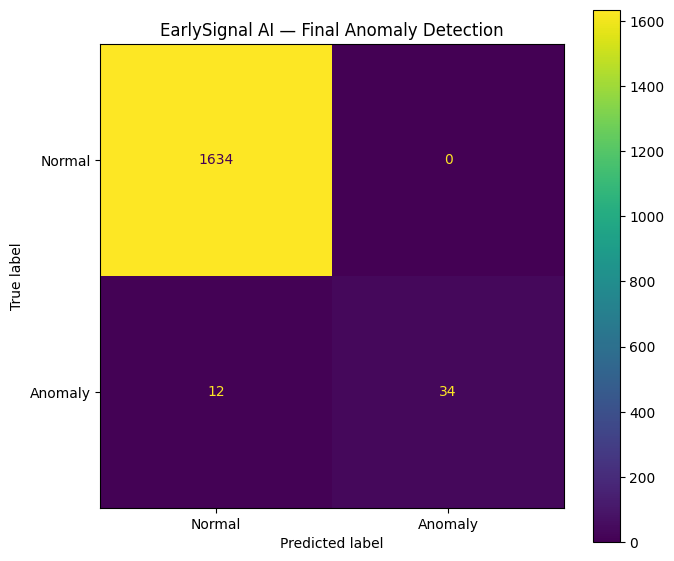

In [27]:
# ============================================================
# 27. Visualize final anomaly confusion matrix
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=final_anomaly_cm,
    display_labels=[
        "Normal",
        "Anomaly"
    ]
)

display_cm.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "EarlySignal AI — Final Anomaly Detection"
)

plt.tight_layout()
plt.show()

## Build standardized anomaly results

In [28]:
# ============================================================
# 28. Build standardized anomaly results
# ============================================================

anomaly_results = test_df[
    [
        "record_id",
        "reporting_date",
        "programme_name",
        "sector",
        "state",
        "lga",
        "community",
        "achievement_rate",
        "reporting_delay_days",
        "complaints_count",
        "supply_delay_days",
        "anomaly_flag"
    ]
].copy()

anomaly_results[
    "predicted_anomaly"
] = final_anomaly_predictions

anomaly_results[
    "anomaly_score"
] = final_anomaly_scores

anomaly_results[
    "anomaly_prediction_correct"
] = (
    anomaly_results["anomaly_flag"]
    == anomaly_results["predicted_anomaly"]
)

print("=" * 70)
print("STANDARDIZED ANOMALY DETECTION RESULTS")
print("=" * 70)

print(
    "\nRows:",
    len(anomaly_results)
)

print(
    "Columns:",
    len(anomaly_results.columns)
)

print("\nOutput columns:")

for column in anomaly_results.columns:
    print(f" - {column}")

print("\nPreview:")

display(
    anomaly_results.head()
)

STANDARDIZED ANOMALY DETECTION RESULTS

Rows: 1680
Columns: 15

Output columns:
 - record_id
 - reporting_date
 - programme_name
 - sector
 - state
 - lga
 - community
 - achievement_rate
 - reporting_delay_days
 - complaints_count
 - supply_delay_days
 - anomaly_flag
 - predicted_anomaly
 - anomaly_score
 - anomaly_prediction_correct

Preview:


,record_id,reporting_date,programme_name,sector,state,lga,community,achievement_rate,reporting_delay_days,complaints_count,supply_delay_days,anomaly_flag,predicted_anomaly,anomaly_score,anomaly_prediction_correct
6160,ES-002426,2026-02-01,Livelihood Recovery Initiative,Livelihoods,Borno,Bama,Bama Site 4,0.6450,4,4,45,1,1,0.046976,True
6163,ES-001082,2026-02-01,Community Resilience Programme,Protection/Resilience,Borno,Ngala,Ngala Site 4,0.5929,8,3,6,0,0,-0.168844,True
6162,ES-000794,2026-02-01,Community Resilience Programme,Protection/Resilience,Borno,Bama,Bama Site 1,0.7083,7,4,7,0,0,-0.206249,True
6161,ES-005114,2026-02-01,Nutrition Support Programme,Nutrition,Borno,Konduga,Konduga Site 4,0.7184,5,0,13,0,0,-0.076304,True
6159,ES-005978,2026-02-01,Nutrition Support Programme,Nutrition,Borno,Gwoza,Gwoza Site 1,0.6679,3,1,5,0,0,-0.191002,True


## Rank most unusual observations

In [29]:
# ============================================================
# 29. Highest-priority anomaly alerts
# ============================================================

highest_anomaly_cases = (
    anomaly_results[
        [
            "reporting_date",
            "programme_name",
            "sector",
            "state",
            "lga",
            "community",
            "achievement_rate",
            "reporting_delay_days",
            "complaints_count",
            "supply_delay_days",
            "predicted_anomaly",
            "anomaly_score"
        ]
    ]
    .sort_values(
        "anomaly_score",
        ascending=False
    )
    .head(20)
)

print("=" * 70)
print("HIGHEST-PRIORITY ANOMALY ALERTS")
print("=" * 70)

display(
    highest_anomaly_cases
)

HIGHEST-PRIORITY ANOMALY ALERTS


,reporting_date,programme_name,sector,state,lga,community,achievement_rate,reporting_delay_days,complaints_count,supply_delay_days,predicted_anomaly,anomaly_score
6306,2026-03-01,Livelihood Recovery Initiative,Livelihoods,Borno,Gwoza,Gwoza Site 4,0.8788,10,2,48,1,0.106902
6676,2026-04-01,Nutrition Support Programme,Nutrition,Borno,Gwoza,Gwoza Site 3,0.6906,14,4,50,1,0.104081
6485,2026-04-01,Livelihood Recovery Initiative,Livelihoods,Borno,Bama,Bama Site 5,0.6851,10,32,11,1,0.097772
6936,2026-05-01,Education Access Project,Education,Borno,Konduga,Konduga Site 1,0.9592,3,22,8,1,0.095942
6354,2026-03-01,Livelihood Recovery Initiative,Livelihoods,Borno,Bama,Bama Site 2,0.7053,8,1,47,1,0.076248
7482,2026-08-01,Livelihood Recovery Initiative,Livelihoods,Borno,Dikwa,Dikwa Site 6,0.5137,4,5,35,1,0.066487
6665,2026-04-01,Livelihood Recovery Initiative,Livelihoods,Borno,Ngala,Ngala Site 5,0.7560,3,1,46,1,0.058939
6524,2026-04-01,Community Resilience Programme,Protection/Resilience,Borno,Bama,Bama Site 1,0.7098,2,33,2,1,0.057965
6369,2026-03-01,Livelihood Recovery Initiative,Livelihoods,Borno,Bama,Bama Site 1,0.6946,8,3,45,1,0.057099
6304,2026-03-01,Livelihood Recovery Initiative,Livelihoods,Borno,Mafa,Mafa Site 6,0.7323,3,1,45,1,0.055706


## Save final model and results

In [30]:
# ============================================================
# 30. Save final anomaly model and outputs
# ============================================================

ANOMALY_MODEL_PATH = (
    MODEL_DIR
    / "earlysignal_anomaly_model.joblib"
)

ANOMALY_RESULTS_PATH = (
    OUTPUT_DIR
    / "anomaly_results.csv"
)

joblib.dump(
    final_anomaly_model,
    ANOMALY_MODEL_PATH
)

anomaly_results.to_csv(
    ANOMALY_RESULTS_PATH,
    index=False
)

print("=" * 70)
print("EARLYSIGNAL AI — ANOMALY MODEL AND OUTPUTS SAVED")
print("=" * 70)

print("\nModel saved to:")
print(ANOMALY_MODEL_PATH)

print(
    "Model file exists:",
    ANOMALY_MODEL_PATH.exists()
)

print("\nAnomaly results saved to:")
print(ANOMALY_RESULTS_PATH)

print(
    "Anomaly results file exists:",
    ANOMALY_RESULTS_PATH.exists()
)

print(
    "\nAnomaly rows saved:",
    len(anomaly_results)
)

print(
    "Anomaly columns saved:",
    len(anomaly_results.columns)
)

EARLYSIGNAL AI — ANOMALY MODEL AND OUTPUTS SAVED

Model saved to:
C:\Users\Ezekiel Mbaya\myenv\EarlySignal_AI\models\earlysignal_anomaly_model.joblib
Model file exists: True

Anomaly results saved to:
C:\Users\Ezekiel Mbaya\myenv\EarlySignal_AI\outputs\anomaly_results.csv
Anomaly results file exists: True

Anomaly rows saved: 1680
Anomaly columns saved: 15


## Final Notebook 05 summary

In [31]:
# ============================================================
# 31. Final Anomaly Detection summary
# ============================================================

print("=" * 72)
print("EARLYSIGNAL AI — ANOMALY DETECTION SUMMARY")
print("=" * 72)

print(
    f"Training observations: {len(X_train_final):,}"
)

print(
    f"Testing observations: {len(X_test_final):,}"
)

print(
    "\nSelected model: Isolation Forest"
)

print(
    f"Selected feature set: "
    f"{best_feature_set_name}"
)

print(
    f"Number of features: "
    f"{len(final_anomaly_features)}"
)

print(
    f"Contamination assumption: "
    f"{best_contamination:.2%}"
)

print("\nHeld-out test performance:")

print(
    f"Precision: {final_anomaly_precision:.4f}"
)

print(
    f"Recall:    {final_anomaly_recall:.4f}"
)

print(
    f"F1 Score:  {final_anomaly_f1:.4f}"
)

print("\nKnown-anomaly detection:")

print(
    f"Known anomalies:       "
    f"{int(final_tp + final_fn):,}"
)

print(
    f"Detected anomalies:    "
    f"{int(final_tp):,}"
)

print(
    f"Missed anomalies:      "
    f"{int(final_fn):,}"
)

print(
    f"False anomaly alerts:  "
    f"{int(final_fp):,}"
)

print("\nLeakage audit: PASSED")

print(
    "Configuration note: feature set and contamination "
    "were selected using a pre-test validation period."
)

print(
    "Validation note: performance reflects held-out "
    "evaluation on synthetic monitoring data."
)

print(
    "Decision-use note: anomaly alerts identify unusual "
    "patterns recommended for human review."
)

print("\nNotebook 05 complete.")

EARLYSIGNAL AI — ANOMALY DETECTION SUMMARY
Training observations: 6,000
Testing observations: 1,680

Selected model: Isolation Forest
Selected feature set: Core Warning Signals
Number of features: 4
Contamination assumption: 2.00%

Held-out test performance:
Precision: 1.0000
Recall:    0.7391
F1 Score:  0.8500

Known-anomaly detection:
Known anomalies:       46
Detected anomalies:    34
Missed anomalies:      12
False anomaly alerts:  0

Leakage audit: PASSED
Configuration note: feature set and contamination were selected using a pre-test validation period.
Validation note: performance reflects held-out evaluation on synthetic monitoring data.
Decision-use note: anomaly alerts identify unusual patterns recommended for human review.

Notebook 05 complete.
